# Function 6

<b> Description of the Sample Application:</b> You’re optimising a cake recipe using a black-box function with five ingredient inputs, for example flour, sugar, eggs, butter and milk. Each recipe is evaluated with a combined score based on flavour, consistency, calories, waste and cost, where each factor contributes negative points as judged by an expert taster. This means the total score is negative by design. 
To frame this as a maximisation problem, your goal is to bring that score as close to zero as possible or, equivalently, to maximise the negative of the total sums



In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

# Load and Analyse the Data

In [57]:
# File Names
input_file  = "initial_inputs.npy"
output_file = "initial_outputs.npy"

# Load the Files
X       = np.load(input_file)
y       = np.load(output_file)

# Analyse the Input Data
print("Input  Shape:", X.shape)
print("Inputs:\n", X)
print()

# Analyse the Output Data
print("Output Shape:", y.shape)
print("Outputs:\n", y)
print()

print(f"y Range: [: {y.min()}, {y.max()}]")
best_idx   = np.argmax(y)
print(f"Best point: x = {X[best_idx]}, y = {y[best_idx]}")
print()

# Converting the Input and Output into a DataFram
ingredient_names = ["flour", "sugar", "eggs", "butter", "milk"]
df         = pd.DataFrame(X, columns = [ingredient_names])
df['y'] = y
print("Data Frame:\n", df)


Input  Shape: (20, 5)
Inputs:
 [[0.7281861  0.15469257 0.73255167 0.69399651 0.05640131]
 [0.24238435 0.84409997 0.5778091  0.67902128 0.50195289]
 [0.72952261 0.7481062  0.67977464 0.35655228 0.67105368]
 [0.77062024 0.11440374 0.04677993 0.64832428 0.27354905]
 [0.6188123  0.33180214 0.18728787 0.75623847 0.3288348 ]
 [0.78495809 0.91068235 0.7081201  0.95922543 0.0049115 ]
 [0.14511079 0.8966846  0.89632223 0.72627154 0.23627199]
 [0.94506907 0.28845905 0.97880576 0.96165559 0.59801594]
 [0.12572016 0.86272469 0.02854433 0.24660527 0.75120624]
 [0.75759436 0.35583141 0.0165229  0.4342072  0.11243304]
 [0.5367969  0.30878091 0.41187929 0.38822518 0.5225283 ]
 [0.95773967 0.23566857 0.09914585 0.15680593 0.07131737]
 [0.6293079  0.80348368 0.81140844 0.04561319 0.11062446]
 [0.02173531 0.42808424 0.83593944 0.48948866 0.51108173]
 [0.43934426 0.69892383 0.42682022 0.10947609 0.87788847]
 [0.25890557 0.79367771 0.6421139  0.19667346 0.59310318]
 [0.43216593 0.71561781 0.3418191  0.7049

# Data Exploration

In [29]:
# Basic Staistics
print("Display Basic Statistics for the Dataset\n",df.describe())

Display Basic Statistics for the Dataset
            flour      sugar       eggs     butter       milk          y
count  20.000000  20.000000  20.000000  20.000000  20.000000  20.000000
mean    0.547765   0.562570   0.467217   0.534433   0.423745  -1.495390
std     0.303015   0.283617   0.315292   0.280259   0.297199   0.460664
min     0.021735   0.114404   0.016523   0.045613   0.004911  -2.571170
25%     0.254775   0.304453   0.165252   0.329066   0.111981  -1.713639
50%     0.624060   0.617630   0.435052   0.621691   0.506517  -1.446370
75%     0.773685   0.813638   0.714228   0.710318   0.628985  -1.227829
max     0.957740   0.931871   0.978806   0.961656   0.892819  -0.714265


In [31]:
# Check for Missing Values in the Data Set
print("Missing Values in the Dataset\n",df.isnull().sum())

Missing Values in the Dataset
 flour     0
sugar     0
eggs      0
butter    0
milk      0
y         0
dtype: int64


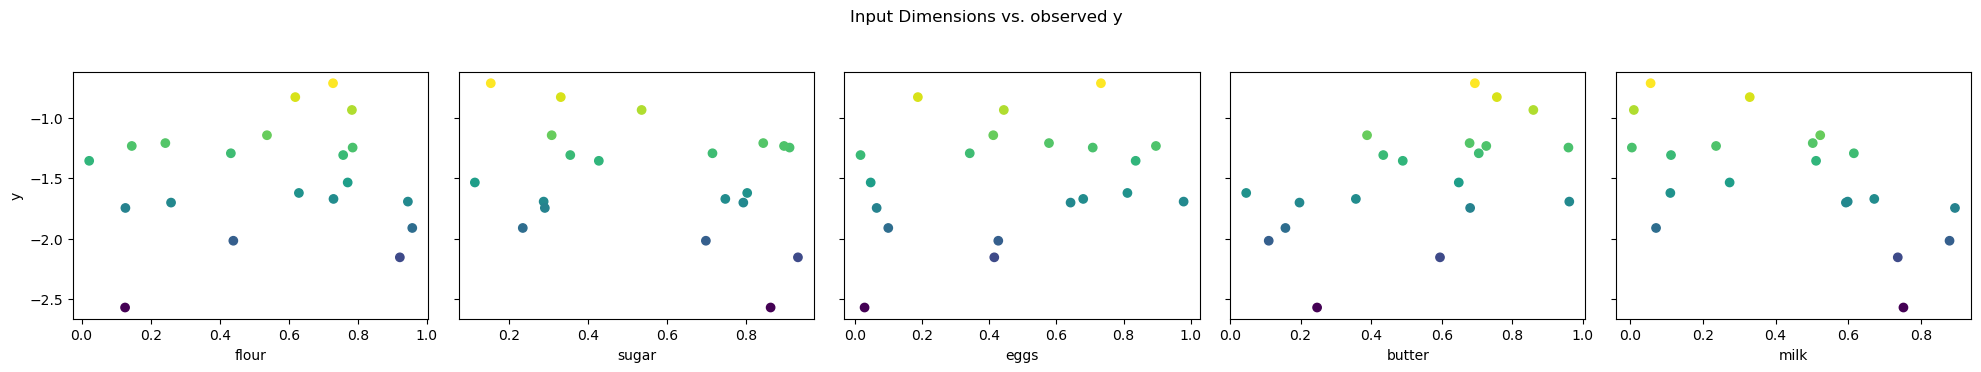

In [94]:
# Pairwise Scatter Plot, showing relationship of y for each input
fig, axes = plt.subplots(1, len(ingredient_names), figsize = (4 * len(ingredient_names), 3.5), sharey = True)
for ax, col in zip(axes, ingredient_names):
    ax.scatter(df[col], df['y'], c = df['y'], cmap = 'viridis')
    ax.set_xlabel(col)
axes[0].set_ylabel('y')
plt.suptitle("Input Dimensions vs. observed y", y = 1.05)
plt.tight_layout()
plt.show()

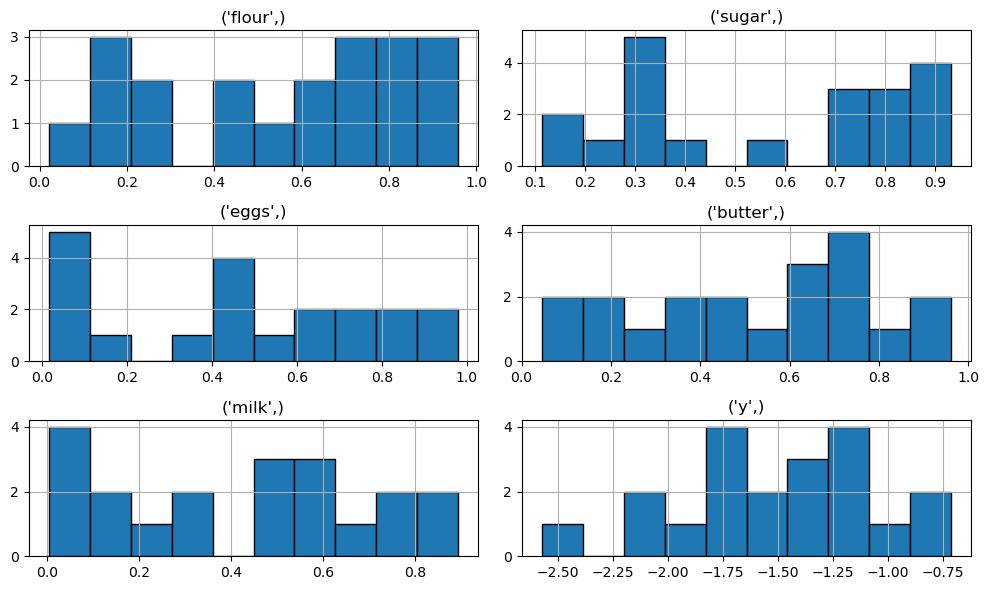

In [80]:
# Plot Histogram Visualisation for the columns of the DataFrame
df.hist(figsize = (10, 6), bins = 10, edgecolor = 'k' )
plt.tight_layout()
plt.show()

In [45]:
# Understanding Correlation between each input with y
print("Correlation of each input with y:\n")

for i, lab in enumerate(ingredient_names):
    corr = np.corrcoef(X[:, i], y)[0, 1]
    print(f" corr({lab}, y) = {corr}")

Correlation of each input with y:

 corr(flour, y) = 0.09540823252686836
 corr(sugar, y) = -0.33044282253347984
 corr(eggs, y) = 0.2586266115415236
 corr(butter, y) = 0.5284657528961823
 corr(milk, y) = -0.5840176168726141


<Axes: xlabel='None', ylabel='None'>

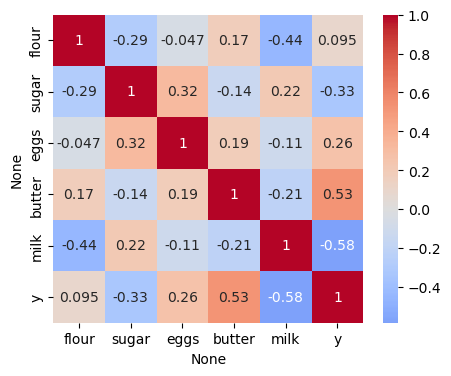

In [47]:
# Plotting the Correlation heatmap
plt.figure(figsize = (5, 4))
sns.heatmap(df.corr(), annot = True, cmap = "coolwarm", center = 0)

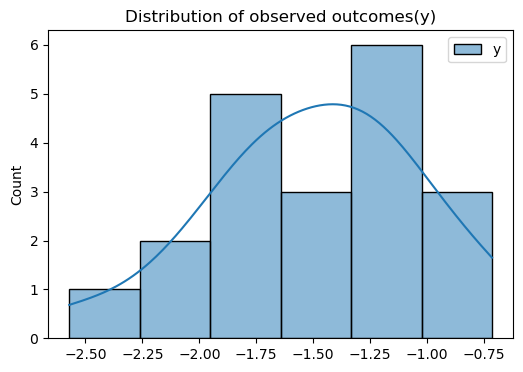

In [49]:
# Plot the Histogram for y to check for Outliers
plt.figure(figsize = (6,4))
sns.histplot(df['y'], kde = True)
plt.title("Distribution of observed outcomes(y)")
plt.show()

# Initialize Gaussian Process

In [96]:
#Define the kernel and initialise the GP model

kernel_rbf = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale = [0.5] * d, length_scale_bounds = (1e-2, 10)) \
                + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-5, 1.0))
gpr   = GaussianProcessRegressor(kernel = kernel_rbf, normalize_y = False, n_restarts_optimizer = 10, random_state = 42 )

# Fit the Gaussian Processes to existing data

In [68]:
# Train the model

gpr.fit(X, y)
print("Learned kernel: ", gpr.kernel_)

Learned kernel:  2.76**2 * RBF(length_scale=[0.814, 4.86, 4.83, 3.73, 5.37]) + WhiteKernel(noise_level=0.0251)


# Compute the UCB acquisition function

- UCB(x)=μ(x)+β⋅σ(x)
- A high beta favors exploration (uncertainty) over exploitation (predicted mean).
- Week 1 uses beta = 2.5, reflecting the 90:10 exploration-heavy strategy.

In [84]:
# Setting a higher beta(= 2.5) for Week -1
beta         = 2.5

# Function to calculatee UCB 
def ucb(X_query, gpr, beta):
    mu, std  = gpr.predict(X_query, return_std = True)
    return mu + beta * std

rng          = np.random.default_rng(42)
candidates   = rng.uniform(0, 1, size = (10000, d))

ucb_values   = ucb(candidates, gpr, beta)
best_ucb_idx = np.argmax(ucb_values)
next_point   = candidates[best_ucb_idx]

print(f"Suggested next Query Point: {next_point}")
print(f"UCB Score: {ucb_values[best_ucb_idx]:.6e}")

Suggested next Query Point: [0.40959444 0.02371308 0.77122945 0.96648988 0.1309728 ]
UCB Score: 5.596167e-01


# Perform Visualisation

# Portal Submission 

In [90]:
# Format as required by the capstone portal: x1-x2 (6 decimal places)
def format_submission(x):
    return "-".join(f"{v}" for v in x)

submission_str = format_submission(next_point)
print(f"Points to be submitted(Week 1):\n{submission_str}")

Points to be submitted(Week 1):
0.40959444497828257-0.02371308058178534-0.7712294548965016-0.9664898830579352-0.13097280072630613
